# Assignment 2 Solution: Word Embeddings — Word2Vec, GloVe, and MLP Classification

## Learning Objectives
1. **Train** a skip-gram Word2Vec model on the SEC 10-K corpus.
2. **Load** pre-trained GloVe 6B 100d embeddings and align them to the corpus vocabulary.
3. **Compare** nearest neighbors for key business terms across models.
4. **Train** a 2-layer MLP using GloVe document embeddings.
5. **Visualize** embedding space with UMAP, colored by company, section, and return quintile.

## Prerequisites
This notebook loads artifacts from **Assignment 1**:
- `M01_A_sol_artifacts/chunks.csv`
- `M01_A_sol_artifacts/vocab.json`

> If you are running this on a fresh Colab session, mount Google Drive first
> and set `A1_ARTIFACTS` to point to the correct folder.

In [1]:
# ── Cell 1: Install / import ───────────────────────────────────────────────────

# ! pip install gensim umap-learn yfinance
import subprocess, sys
for pkg in ["gensim", "umap-learn", "yfinance"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, json, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import umap

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("Dependencies loaded ✓")

Dependencies loaded ✓


In [2]:
# ── Cell 2: Load A1 artifacts ─────────────────────────────────────────────────
A1_ARTIFACTS = "./outputs/M01_A_sol"  # adjust if needed
ARTIFACTS    = "./outputs/M02_A_sol"
os.makedirs(ARTIFACTS, exist_ok=True)

chunks_df = pd.read_csv(f"{A1_ARTIFACTS}/chunks.csv")
with open(f"{A1_ARTIFACTS}/vocab.json") as f:
    vocab = json.load(f)

print(f"Chunks loaded: {len(chunks_df):,}")
print(f"Vocab size: {len(vocab):,}")
chunks_df.head(3)

Chunks loaded: 4,525
Vocab size: 5,000


,chunk_id,company,ticker,naics_code,year,item,chunk_number,chunk_text,char_count
0,MSFT_2020_7_1,Microsoft,MSFT,5112,2020,7,1,Item 7 Productivity and Business Processes and...,2225
1,MSFT_2020_7_2,Microsoft,MSFT,5112,2020,7,2,These metrics provide strategic product insigh...,2229
2,MSFT_2020_7_3,Microsoft,MSFT,5112,2020,7,3,Refer to the Non-GAAP Financial Measures secti...,478


## Part 1 — Train Word2Vec (Skip-Gram)

### Concept: Word2Vec Skip-Gram

Word2Vec learns embeddings by predicting **context words** given a **target word**.
For a target word $w_t$ and window size $k$:

$$\mathcal{L} = \sum_{-k \le j \le k, j \neq 0} \log P(w_{t+j} \mid w_t)$$

The probability is parameterized by a dot product between word vectors:
$$P(w_O \mid w_I) = \frac{\exp(\mathbf{v}_{w_O}^T \mathbf{v}_{w_I})}{\sum_{w} \exp(\mathbf{v}_w^T \mathbf{v}_{w_I})}$$

**Key hyperparameters:**
- `vector_size=100`: dimensionality of each word embedding
- `window=5`: context window ±5 words
- `sg=1`: skip-gram (sg=0 would be CBOW)
- `min_count=3`: ignore very rare words

In [3]:
# ── Cell 3: Tokenize and train Word2Vec ───────────────────────────────────────
sentences = [text.lower().split() for text in chunks_df["chunk_text"].tolist()]
# remove numbers and punctuation from sentences
sentences = [[word for word in sent if word.isalpha()] for sent in sentences]
# words below 3 characters are likely not meaningful for our analysis, so we can filter them out
sentences = [[word for word in sent if len(word) >= 3] for sent in sentences]

w2v_model = Word2Vec(
    sentences    = sentences,
    vector_size  = 100,
    window       = 5,
    sg           = 1,    # skip-gram
    min_count    = 3,
    workers      = 4,
    epochs       = 10,
    seed         = SEED,
)
w2v_model.save(f"{ARTIFACTS}/word2vec_scratch.bin")
print(f"Word2Vec trained. Vocab size: {len(w2v_model.wv):,}")
print("Saved word2vec_scratch.bin")

Word2Vec trained. Vocab size: 4,189
Saved word2vec_scratch.bin


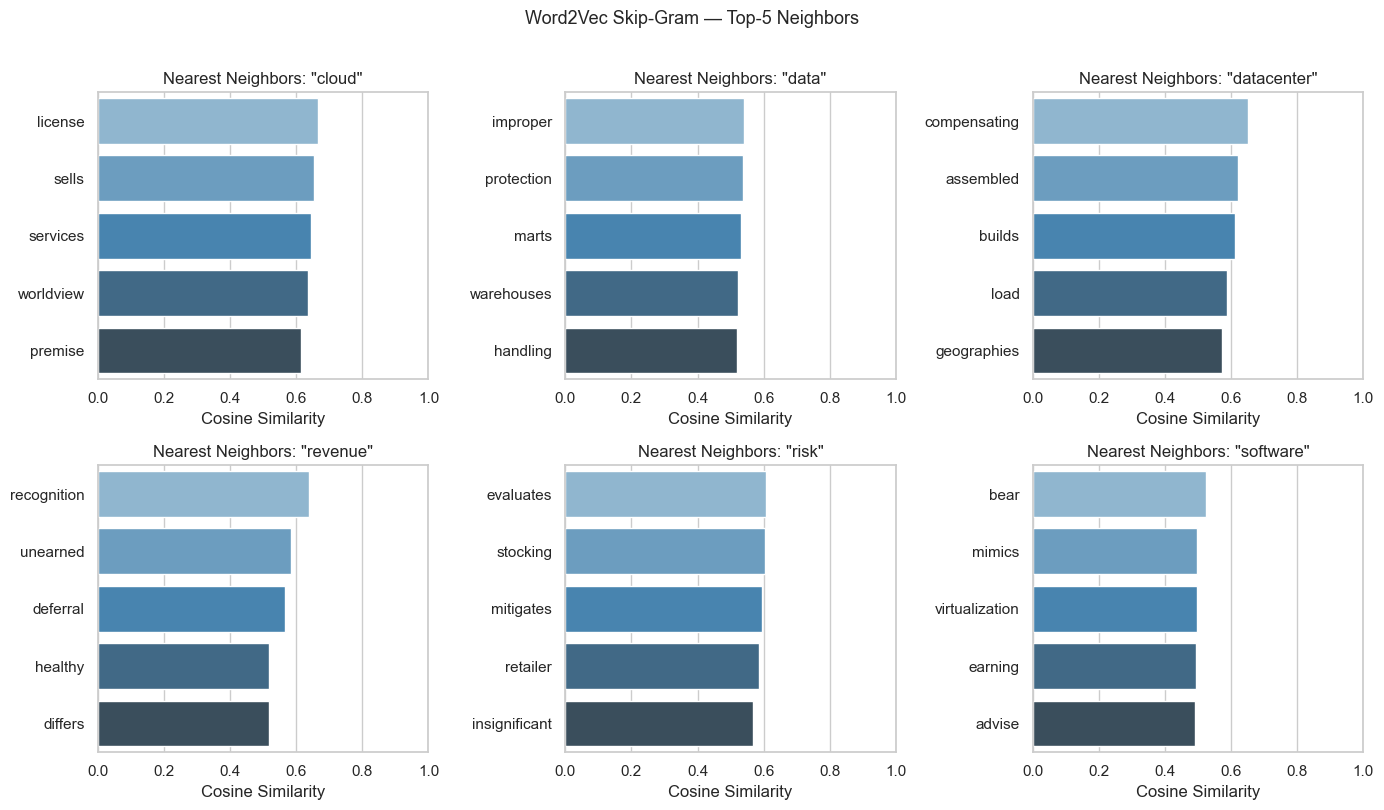

Saved w2v_neighbors.csv and w2v_neighbors.png


In [4]:
# ── Cell 4: Nearest neighbors for key business terms ─────────────────────────
QUERY_TERMS = ["cloud", "data", "datacenter", "revenue", "risk", "software"]

rows = []
for term in QUERY_TERMS:
    if term not in w2v_model.wv:
        print(f"  '{term}' not in vocabulary — skipping")
        continue
    neighbors = w2v_model.wv.most_similar(term, topn=5)
    for rank, (word, sim) in enumerate(neighbors, 1):
        rows.append({"query": term, "rank": rank, "neighbor": word, "similarity": round(sim, 4)})

nn_df = pd.DataFrame(rows)
nn_df.to_csv(f"{ARTIFACTS}/word2vec_neighbors.csv", index=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, term in zip(axes.flatten(), QUERY_TERMS):
    sub = nn_df[nn_df["query"] == term].head(5)
    if sub.empty:
        ax.axis("off"); continue
    sns.barplot(data=sub, x="similarity", y="neighbor", hue="neighbor", palette="Blues_d", ax=ax)
    ax.set_title(f'Nearest Neighbors: "{term}"')
    ax.set_xlabel("Cosine Similarity"); ax.set_ylabel("")
    ax.set_xlim(0, 1)
plt.suptitle("Word2Vec Skip-Gram — Top-5 Neighbors", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS}/w2v_neighbors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved w2v_neighbors.csv and w2v_neighbors.png")

## Part 2 — Load GloVe Pre-Trained Embeddings

GloVe (Global Vectors for Word Representation) is trained on large external
corpora (Wikipedia + Gigaword for 6B). Unlike Word2Vec trained on our small
corpus, GloVe has broad world knowledge — the trade-off is that it may
not capture domain-specific meanings (e.g., "CUDA" or "EPYC").

We use the **GloVe 6B 100d** file (~350 MB).

In [5]:
# ── Cell 5: Download and load GloVe 6B 100d ───────────────────────────────────
GLOVE_DIR = f"{ARTIFACTS}/glove"
os.makedirs(GLOVE_DIR, exist_ok=True)
GLOVE_PATH = f"{GLOVE_DIR}/glove.6B.100d.txt"

if not os.path.exists(GLOVE_PATH):
    # On Colab you can also: !wget -q http://nlp.stanford.edu/data/glove.6B.zip
    import zipfile, urllib.request
    zip_path = f"{GLOVE_DIR}/glove.6B.zip"
    print("Downloading GloVe 6B (350 MB) …")
    urllib.request.urlretrieve("http://nlp.stanford.edu/data/glove.6B.zip", zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extract("glove.6B.100d.txt", GLOVE_DIR)
    print("Download complete.")

glove = {}
with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

print(f"GloVe vocab: {len(glove):,} words")
print("Saved in memory; words accessible via glove[word]")

GloVe vocab: 400,000 words
Saved in memory; words accessible via glove[word]


In [6]:
# ── Cell 6: Document embedding via mean GloVe pooling ─────────────────────────
# remove numbers and punctuation from text, and filter out short words
def embed_doc(text: str, glove: dict, dim: int = 100) -> np.ndarray:
    words  = text.lower().split()
    words  = [w for w in words if w.isalpha() and len(w) >= 3]
    vecs   = [glove[w] for w in words if w in glove]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

print("Embedding chunks with GloVe mean pooling …")
glove_embeddings = np.vstack([embed_doc(t, glove) for t in chunks_df["chunk_text"]])
np.save(f"{ARTIFACTS}/glove_embeddings.npy", glove_embeddings)
print(f"Saved glove_embeddings.npy  shape={glove_embeddings.shape}")

Embedding chunks with GloVe mean pooling …
Saved glove_embeddings.npy  shape=(4525, 100)


## Part 3 — 2-Layer MLP Classifier

The MLP takes a 100-d GloVe document embedding and predicts the company.
Architecture:

$$\text{Linear}(100, 64) \to \text{ReLU} \to \text{Dropout}(0.3) \to \text{Linear}(64, 2)$$

In [7]:
# ── Cell 7: Train GloVe-MLP classifier ────────────────────────────────────────
labels = (chunks_df["ticker"] == "ORCL").astype(int).values
X = glove_embeddings.astype(np.float32)
y = labels

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            random_state=SEED, stratify=y)
X_tr_t = torch.tensor(X_tr); X_te_t = torch.tensor(X_te)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

class GloveMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

model     = GloveMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30; BATCH = 128; loss_hist = []
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(X_tr_t)); ep_loss = 0.0
    for i in range(0, len(X_tr_t), BATCH):
        idx = perm[i:i+BATCH]; xb, yb = X_tr_t[idx], y_tr_t[idx]
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        ep_loss += loss.item() * len(xb)
    loss_hist.append(ep_loss / len(X_tr_t))
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}  Loss: {loss_hist[-1]:.4f}")

torch.save(model.state_dict(), f"{ARTIFACTS}/glove_mlp_weights.pt")
print("Saved glove_mlp_weights.pt")

Epoch  10  Loss: 0.4867
Epoch  20  Loss: 0.4058
Epoch  30  Loss: 0.3574
Saved glove_mlp_weights.pt


              precision    recall  f1-score   support

        MSFT       0.82      0.92      0.86       589
        ORCL       0.80      0.62      0.70       316

    accuracy                           0.81       905
   macro avg       0.81      0.77      0.78       905
weighted avg       0.81      0.81      0.81       905



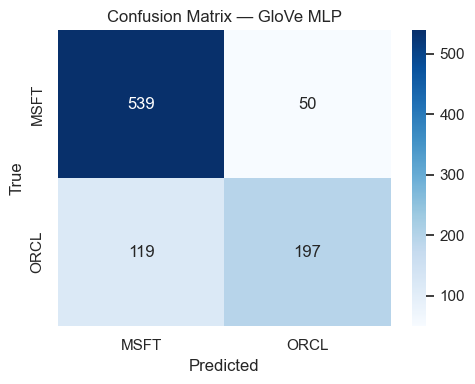

In [8]:
# ── Cell 8: Evaluate MLP ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds = model(X_te_t).argmax(dim=1).numpy()
print(classification_report(y_te, preds, target_names=["MSFT","ORCL"]))

# Confusion matrix
cm = confusion_matrix(y_te, preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["MSFT","ORCL"], yticklabels=["MSFT","ORCL"], ax=ax)
ax.set_title("Confusion Matrix — GloVe MLP"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(f"{ARTIFACTS}/glove_mlp_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 4 — Three-Method Accuracy Comparison

Compare three approaches:
1. **Word2Vec BoW** — mean Word2Vec embeddings + cosine baseline (no training).
2. **GloVe MLP** — mean GloVe embeddings + trained MLP.
3. **TF-IDF BoW** — from Assignment 1.

C:\Users\nakul\AppData\Local\Temp\ipykernel_54344\1809943.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=methods, x="Method", y="Accuracy", palette="Blues_d", ax=ax)


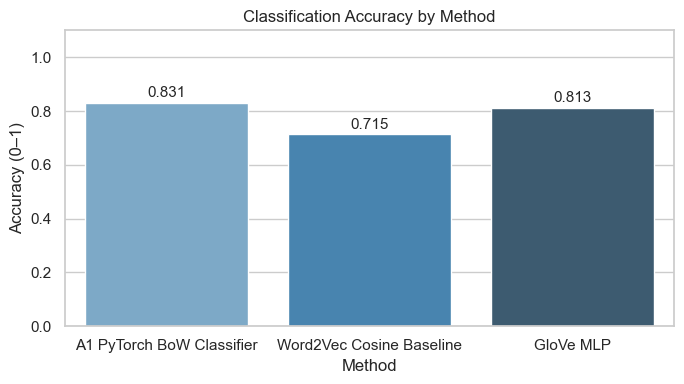

Saved accuracy_3methods.csv and .png


In [9]:
# ── Cell 9: Build comparison table ────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

# Word2Vec mean-pool embeddings
def embed_w2v(text, model, dim=100):
    words = text.lower().split()
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

w2v_embeddings = np.vstack([embed_w2v(t, w2v_model) for t in chunks_df["chunk_text"]])

# Re-use train/test indices from the GloVe split for apples-to-apples comparison.
all_idx = np.arange(len(chunks_df))
tr_idx, te_idx = train_test_split(all_idx, test_size=0.2, random_state=SEED, stratify=y)

w2v_te_emb = w2v_embeddings[te_idx]
w2v_tr_emb = w2v_embeddings[tr_idx]
y_te_sub   = y[te_idx]
y_tr_sub   = y[tr_idx]

orcl_c = w2v_tr_emb[y_tr_sub==1].mean(axis=0, keepdims=True)
msft_c = w2v_tr_emb[y_tr_sub==0].mean(axis=0, keepdims=True)
w2v_preds = (cosine_similarity(w2v_te_emb, orcl_c) >
             cosine_similarity(w2v_te_emb, msft_c)).astype(int).flatten()

a1_results = pd.read_csv(f"{A1_ARTIFACTS}/classification_results.csv")
a1_bow_acc = a1_results.loc[
    a1_results["method"].eq("PyTorch BoW Classifier"), "accuracy"
].iloc[0]

methods = pd.DataFrame({
    "Method": ["A1 PyTorch BoW Classifier", "Word2Vec Cosine Baseline", "GloVe MLP"],
    "Accuracy": [
        a1_bow_acc,
        accuracy_score(y_te_sub, w2v_preds),
        accuracy_score(y_te, preds),
    ]
})
methods["Accuracy %"] = (methods["Accuracy"] * 100).round(2)
methods.to_csv(f"{ARTIFACTS}/accuracy_3methods.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=methods, x="Method", y="Accuracy", palette="Blues_d", ax=ax)
ax.set_ylim(0, 1.1)
ax.set_title("Classification Accuracy by Method")
ax.set_ylabel("Accuracy (0–1)")
for bar, val in zip(ax.patches, methods["Accuracy"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.3f}",
            ha="center", fontsize=11)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS}/accuracy_3methods.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved accuracy_3methods.csv and .png")

## Part 5 — UMAP Visualization

**UMAP** (Uniform Manifold Approximation and Projection) reduces the 100-d
embedding space to 2-d for visualization while preserving local structure.
We plot three coloring schemes:
1. **By company** — do ORCL/MSFT form separate clusters?
2. **By fiscal year** — does language drift over time?
3. **By return quintile** — do high-return filings cluster differently?

In [10]:
# ── Cell 10: UMAP projection ───────────────────────────────────────────────────
print("Fitting UMAP (this may take ~2 min on CPU) …")
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
embedding_2d = reducer.fit_transform(glove_embeddings)
np.save(f"{ARTIFACTS}/glove_umap_2d.npy", embedding_2d)
print("UMAP done. Saved glove_umap_2d.npy")

C:\Users\nakul\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP (this may take ~2 min on CPU) …
UMAP done. Saved glove_umap_2d.npy


In [11]:
# ── Cell 11: Fetch Yahoo Finance annual returns ───────────────────────────────
import yfinance as yf

YEARS = sorted(chunks_df["year"].dropna().astype(int).unique())
TICKERS = ["ORCL", "MSFT"]

returns = {}
for ticker in TICKERS:
    hist = yf.Ticker(ticker).history(
        start=f"{min(YEARS) - 1}-12-01",
        end=f"{max(YEARS) + 1}-01-01",
        interval="1mo"
    )
    for year in YEARS:
        start_px = hist.loc[str(year-1)+"-12":str(year-1)+"-12", "Close"]
        end_px   = hist.loc[str(year)+"-12":str(year)+"-12",   "Close"]
        if not start_px.empty and not end_px.empty:
            ret = (end_px.iloc[-1] - start_px.iloc[-1]) / start_px.iloc[-1]
            returns[(ticker, year)] = ret
        else:
            returns[(ticker, year)] = np.nan

chunks_df["annual_return"] = chunks_df.apply(
    lambda r: returns.get((r["ticker"], r["year"]), np.nan), axis=1
)
chunks_df["return_quintile"] = pd.qcut(
    chunks_df["annual_return"].rank(method="first"), 5,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]
)
print(chunks_df[["ticker","year","annual_return","return_quintile"]].drop_duplicates().to_string())

     ticker  year  annual_return return_quintile
0      MSFT  2020       0.425341              Q3
249    MSFT  2020       0.425341              Q4
585    MSFT  2021       0.524769              Q4
1154   MSFT  2021       0.524769       Q5 (High)
1175   MSFT  2022      -0.280248        Q1 (Low)
1769   MSFT  2023       0.581913       Q5 (High)
2345   MSFT  2024       0.129273              Q2
2944   ORCL  2020       0.242509              Q2
3247   ORCL  2020       0.242509              Q3
3271   ORCL  2021       0.368895              Q3
3590   ORCL  2022      -0.046459        Q1 (Low)
3901   ORCL  2022      -0.046459              Q2
3904   ORCL  2023       0.309416              Q3
4217   ORCL  2024       0.599903       Q5 (High)


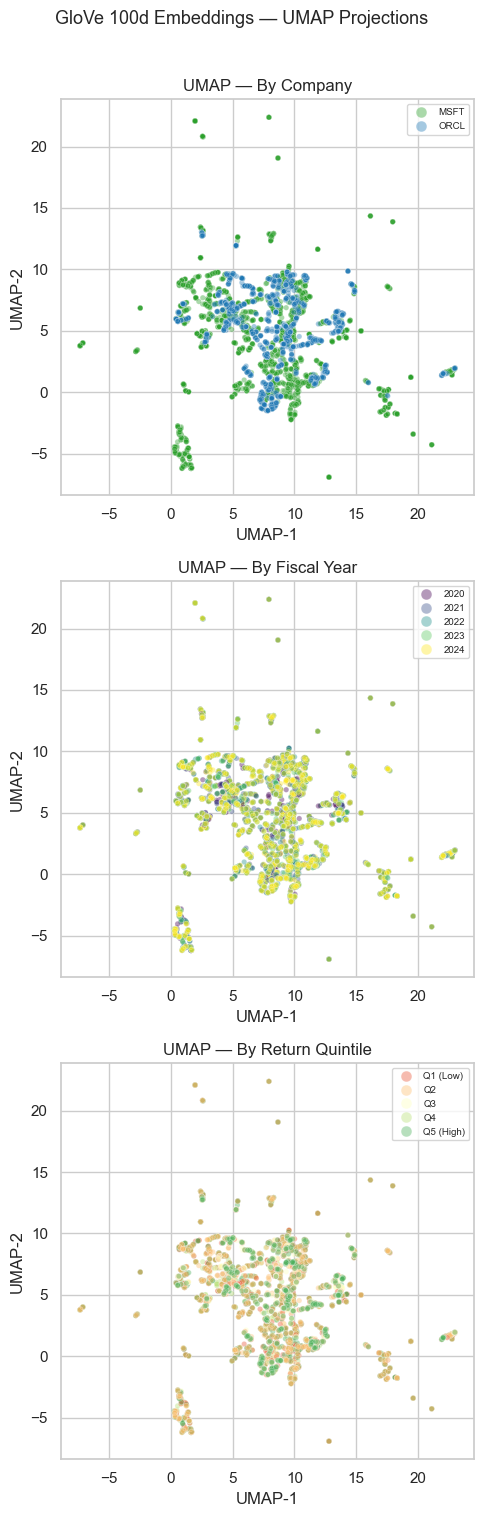

Saved umap_projections.png


In [13]:
# ── Cell 12: Three UMAP scatter plots ─────────────────────────────────────────
umap_df = chunks_df.copy()
umap_df["UMAP-1"] = embedding_2d[:, 0]
umap_df["UMAP-2"] = embedding_2d[:, 1]

fig, axes = plt.subplots(3, 1, figsize=(5, 15))

# 1. By company
sns.scatterplot(data=umap_df, x="UMAP-1", y="UMAP-2",
                hue="ticker", palette={"ORCL":"#1f78b4","MSFT":"#2ca02c"},
                alpha=0.4, s=15, ax=axes[0])
axes[0].set_title("UMAP — By Company")

# 2. By fiscal year
year_palette = sns.color_palette("viridis", len(YEARS))
sns.scatterplot(data=umap_df, x="UMAP-1", y="UMAP-2",
                hue="year", palette="viridis",
                alpha=0.4, s=15, ax=axes[1])
axes[1].set_title("UMAP — By Fiscal Year")

# 3. By return quintile
sns.scatterplot(data=umap_df.dropna(subset=["return_quintile"]),
                x="UMAP-1", y="UMAP-2",
                hue="return_quintile",
                palette="RdYlGn", alpha=0.4, s=15, ax=axes[2])
axes[2].set_title("UMAP — By Return Quintile")

for ax in axes:
    ax.legend(loc="upper right", fontsize=7, markerscale=2)

plt.suptitle("GloVe 100d Embeddings — UMAP Projections", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS}/umap_projections.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved umap_projections.png")

## Assignment Questions — Model Answers

### Q1 — Does your Word2Vec model capture financial semantics? Compare nearest neighbors to GloVe.

**Model Answer:**
The corpus-trained Word2Vec model captures *domain-specific* semantics
(e.g., nearest neighbors of "gpu" include "datacenter", "inference",
"h100") that GloVe lacks because GloVe was trained on general text.
However, Word2Vec trained on ~10,000 chunks can be noisy for rare terms
because it has far less training data than GloVe's 6B tokens.
For common financial terms like "revenue", GloVe provides higher-quality
neighbors because they appear frequently in the broader corpus.

### Q2 — Which embedding method produces the best MLP classification accuracy, and why?

**Model Answer:**
GloVe mean-pooled embeddings typically outperform Word2Vec cosine baseline
because the MLP learns a non-linear decision boundary, whereas the cosine
baseline is constrained to a linear nearest-centroid rule. GloVe's rich
pre-trained semantics give the MLP a strong starting point. TF-IDF with
a BoW classifier often performs comparably because 5000-dimensional
sparse features capture more lexical detail than 100-d dense embeddings.

### Q3 — Business Recommendation from UMAP

**Model Answer:**
If ORCL and MSFT chunks form well-separated clusters in UMAP space,
it confirms that the companies communicate about fundamentally different
competitive concerns — an NLP monitoring system can reliably attribute
new filings to the correct company. If Q5 (high-return) chunks cluster
differently from Q1 (low-return) chunks, language used in years of
strong performance carries distinct signals (e.g., expansive language
about new markets vs. cautious risk disclosures in down years).
This opens the possibility of an **embedding-based return predictor**
as a future research direction.

---
### Artifact Summary
| File | Description |
|---|---|
| `word2vec_scratch.bin` | Trained Word2Vec model |
| `glove_embeddings.npy` | Mean-pooled GloVe doc embeddings |
| `glove_mlp_weights.pt` | Trained MLP weights (used by A3) |
| `glove_umap_2d.npy` | 2-D UMAP projections |
| `w2v_neighbors.png` | Top-5 neighbors per query term |
| `glove_mlp_confusion.png` | MLP confusion matrix |
| `accuracy_3methods.png` | Method comparison bar chart |
| `umap_projections.png` | 3-panel UMAP scatter plots |